In [4]:
import os
import polars as pl
import plotnine as pn

In [8]:
# Check current working directory
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\mlchr\OneDrive\Personal\Projects\heart of the cards\Code


In [9]:
# Import the data
data = pl.read_csv("../Data/combined_data.csv", null_values="NA")

In [11]:
# Get the columns names in first_year
print(data.columns)

['date_pulled', 'time_pulled', 'id', 'name', 'type', 'frameType', 'desc', 'race', 'archetype', 'ygoprodeck_url', 'atk', 'def', 'level', 'attribute', 'pend_desc', 'monster_desc', 'scale', 'linkval', 'cardmarket_price', 'tcgplayer_price', 'ebay_price', 'amazon_price', 'coolstuffinc_price', 'ban_tcg', 'ban_ocg', 'views', 'viewsweek', 'upvotes', 'downvotes', 'tcg_date', 'ocg_date', 'has_effect', 'staple', 'question_atk', 'question_def', 'has_archetype', 'avg_price', 'max_price', 'min_price', 'tcg_exclusive', 'ocg_exclusive', 'restricted_tcg', 'restricted_ocg', 'banned_tcg', 'banned_ocg', 'tcg_months_since_rel', 'ocg_months_since_rel', 'first_market', 'mkt_delay', 'md_rarity', 'humanReadableCardType', 'typeline']


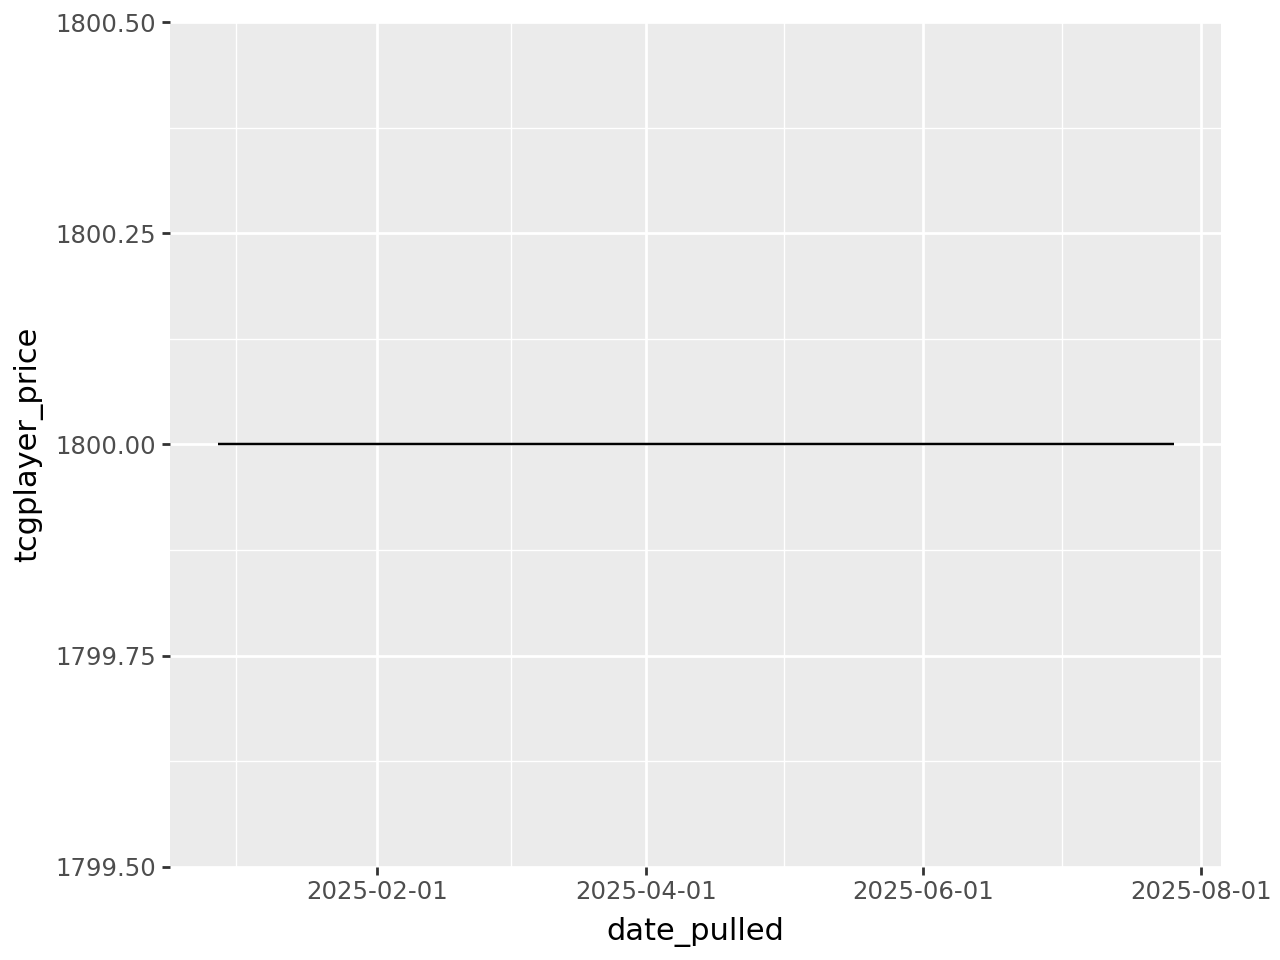

In [13]:
import pandas as pd

dm = data.filter(pl.col("tcgplayer_price") == pl.max("tcgplayer_price")).to_pandas()

# Ensure date_pulled is datetime and sort
dm["date_pulled"] = pd.to_datetime(dm["date_pulled"], errors="coerce")
dm = dm.sort_values("date_pulled")

pn.ggplot(dm, pn.aes(x="date_pulled", y="tcgplayer_price")) + pn.geom_line()

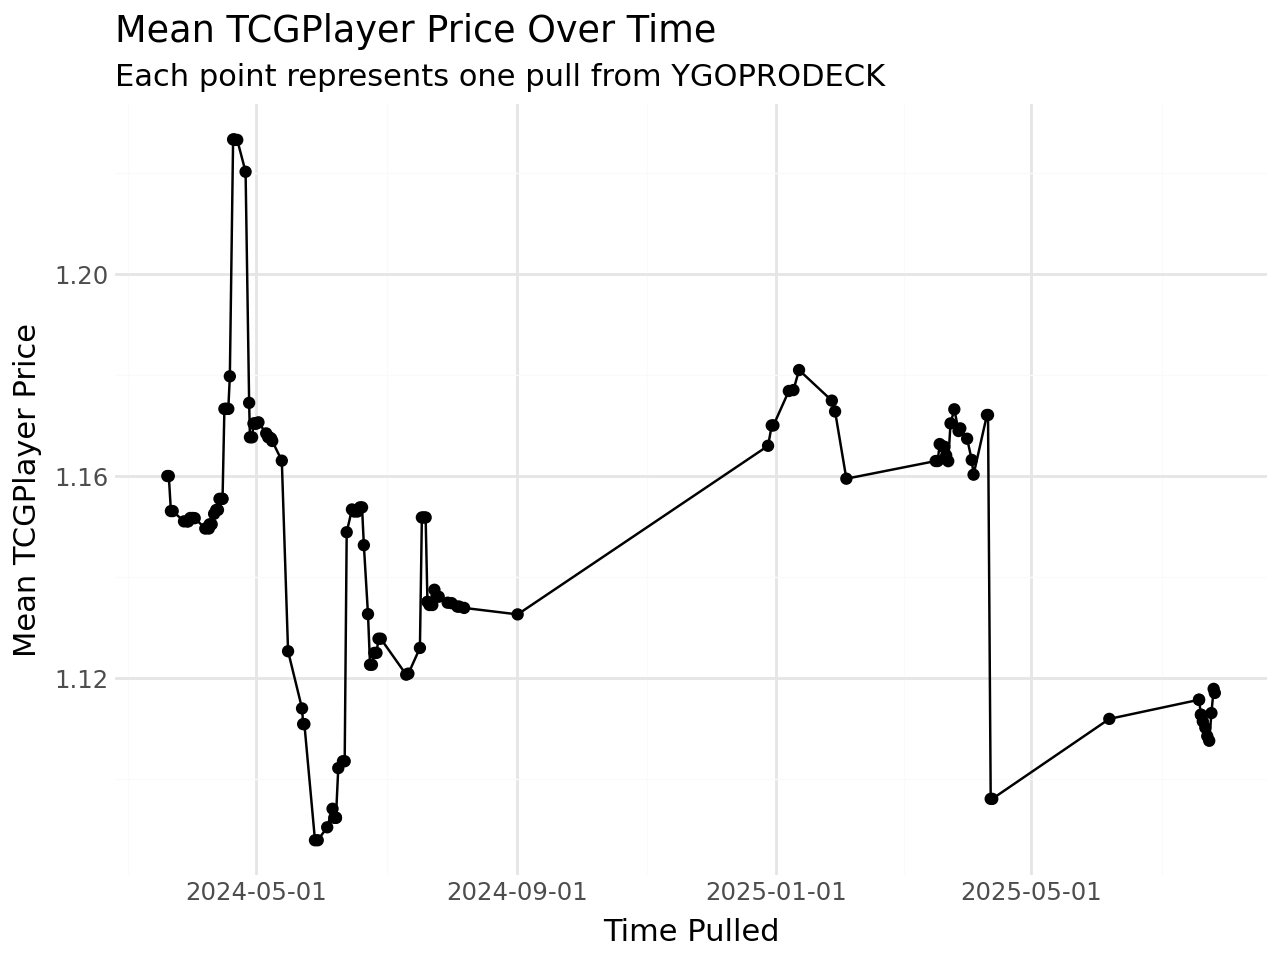

In [21]:
mean_price = data.group_by('time_pulled').agg(pl.col('tcgplayer_price').mean()).sort('time_pulled')

mean_price = mean_price.to_pandas()

mean_price['time_pulled'] = pd.to_datetime(mean_price['time_pulled'], errors='coerce')

pn.ggplot(mean_price, 
          pn.aes(x='time_pulled', 
                 y='tcgplayer_price')) + \
            pn.geom_line() + \
            pn.geom_point() + \
            pn.theme_minimal() + \
            pn.labs(title='Mean TCGPlayer Price Over Time',
                        x='Time Pulled', 
                        y='Mean TCGPlayer Price',
                        subtitle='Each point represents one pull from YGOPRODECK')